# Titanic Environment Test
Verifying Jupyter kernel and environment setup

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split , GridSearchCV




In [263]:
train_df=pd.read_csv("train.csv")
test_df=pd.read_csv("test.csv")
train_df.head(len(train_df.columns))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [264]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [265]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [266]:
train_df.describe(include="O")

C:\Users\student\AppData\Local\Temp\ipykernel_4152\1170404951.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.describe(include="O")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [267]:
train_df.groupby('Pclass', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [268]:
train_df.groupby('Age',as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Age,Survived
0,0.42,1.0
1,0.67,1.0
2,0.75,1.0
3,0.83,1.0
4,0.92,1.0
...,...,...
81,65.00,0.0
83,70.00,0.0
84,70.50,0.0
85,71.00,0.0


In [269]:
train_df.groupby('Sex' , as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [270]:
train_df.groupby('Parch', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [271]:
train_df.groupby('SibSp', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [272]:
#creating a new column called family size by adding the number of siblings/spouses and parents/children together to see if it has any effect on survival rate. .
train_df['FamilySize']=train_df['SibSp']+train_df['Parch']
test_df['FamilySize']=test_df['SibSp']+test_df['Parch']
train_df.groupby('FamilySize', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,FamilySize,Survived
3,3,0.724138
2,2,0.578431
1,1,0.552795
6,6,0.333333
0,0,0.303538
4,4,0.200000
5,5,0.136364
7,7,0.000000
8,10,0.000000


In [273]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,0
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,1


In [274]:
#this is a map to categorize family size into groups for better analysis of survival rates based on family size.
family_map={0:'Alone', 1:'Alone', 2:'Small', 3:'Small', 4:'Medium', 5:'Medium', 6:'Medium', 7:'Large', 8:'Large  ', 9:'Large', 10:'Large',}

In [275]:
train_df['FamilySizeGroup']=train_df['FamilySize'].map(family_map)
test_df['FamilySizeGroup']=test_df['FamilySize'].map(family_map)

In [276]:
train_df.groupby('FamilySizeGroup', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,FamilySizeGroup,Survived
3,Small,0.610687
0,Alone,0.361032
2,Medium,0.204082
1,Large,0.000000


In [277]:
train_df.groupby('Embarked', as_index=False)['Survived'].mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


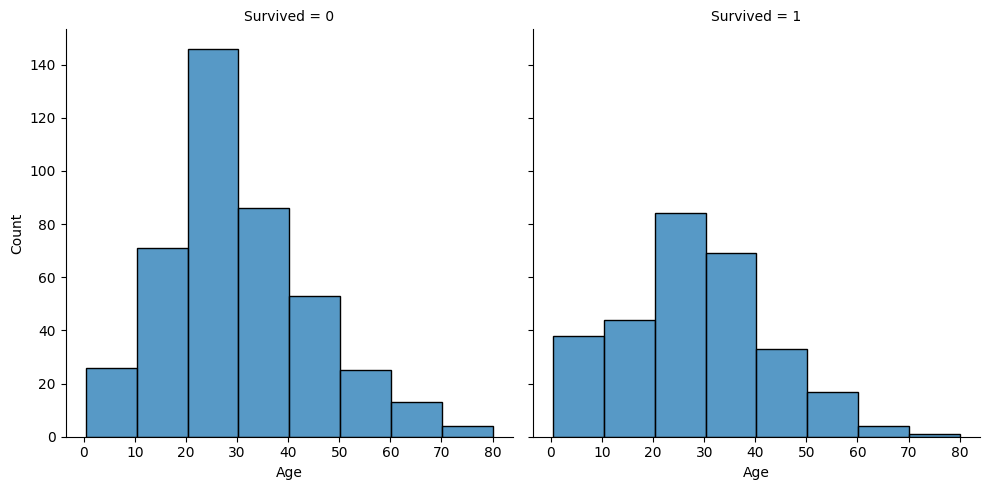

In [278]:
sns.displot(train_df, x='Age', col="Survived", binwidth=10, height=5)

In [279]:
#here we are categorizing age into 8  EQUAL groups to see if it has any effect on survival rate. and because age is a continuous variable, categorizing it into groups can help us analyze the relationship between age and survival more effectively. By using pd.qcut, we can create quantile-based bins that ensure each group has an equal number of observations, which can provide insights into how different age groups fared in terms of survival rates.
train_df["Age_cut"]=pd.qcut(train_df['Age'], 8)
test_df["Age_cut"]=pd.qcut(test_df['Age'], 8)

In [280]:
train_df.groupby('Age_cut', as_index=False)['Survived'].mean().sort_values(by='Age_cut', ascending=True)

,Age_cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


In [281]:
#next we base the 8 equal groups into  ranges of ages for better modeling and analysis of survival rates based on age groups.
train_df.loc[train_df['Age']<=16, "Age"]=0
train_df.loc[(train_df['Age']>16) & (train_df['Age']<=20), 'Age']=1
train_df.loc[(train_df['Age']>20) & (train_df['Age']<=24), 'Age']=2
train_df.loc[(train_df['Age']>24) & (train_df['Age']<=28), 'Age']=3
train_df.loc[(train_df['Age']>28) & (train_df['Age']<=32), 'Age']=4
train_df.loc[(train_df['Age']>32) & (train_df['Age']<=38), 'Age']=5
train_df.loc[(train_df['Age']>38) & (train_df['Age']<=47), 'Age']=6
train_df.loc[(train_df['Age']>47) & (train_df['Age']<=80), 'Age']=7


test_df.loc[test_df['Age']<=16, "Age"]=0
test_df.loc[(test_df['Age']>16) & (test_df['Age']<=20), 'Age']=1
test_df.loc[(test_df['Age']>20) & (test_df['Age']<=24), 'Age']=2
test_df.loc[(test_df['Age']>24) & (test_df['Age']<=28), 'Age']=3
test_df.loc[(test_df['Age']>28) & (test_df['Age']<=32), 'Age']=4
test_df.loc[(test_df['Age']>32) & (test_df['Age']<=38), 'Age']=5
test_df.loc[(test_df['Age']>38) & (test_df['Age']<=47), 'Age']=6
test_df.loc[(test_df['Age']>47) & (test_df['Age']<=80), 'Age']=7

In [282]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,7.2500,NaN,S,1,Alone,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,71.2833,C85,C,1,Alone,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,53.1000,C123,S,1,Alone,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,8.0500,NaN,S,0,Alone,"(32.312, 38.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S,0,Alone,NaN
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,34.6542,A5,C,0,Alone,"(47.0, 80.0]"
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,63.3583,D10 D12,C,1,Alone,"(20.125, 24.0]"
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,23.0000,NaN,S,1,Alone,"(32.312, 38.0]"


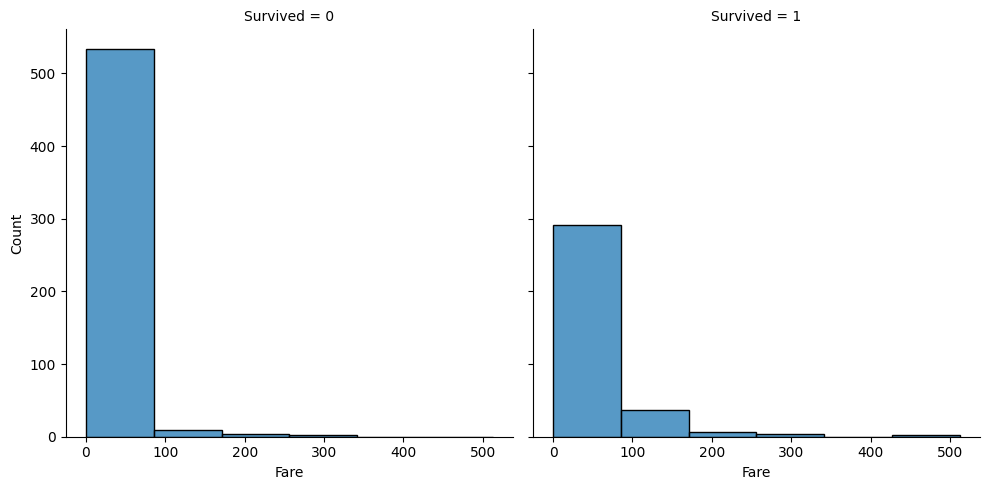

In [283]:
sns.displot(train_df, x="Fare", col="Survived", binwidth=80, height=5)

In [284]:
train_df['Fare_cut']=pd.qcut(train_df['Fare'], q=6)
test_df['Fare_cut']=pd.qcut(test_df['Fare'], q=6)

In [285]:
train_df.groupby('Fare_cut', as_index=False)['Survived'].mean().sort_values(by='Fare_cut', ascending=True)

,Fare_cut,Survived
0,"(-0.001, 7.775]",0.205128
1,"(7.775, 8.662]",0.190789
2,"(8.662, 14.454]",0.366906
3,"(14.454, 26.0]",0.436242
4,"(26.0, 52.369]",0.417808
5,"(52.369, 512.329]",0.697987


In [286]:
train_df.loc[train_df['Fare']<=7.775, 'Fare']=0 
train_df.loc[(train_df['Fare']>7.775) & (train_df['Fare']<=8.662), 'Fare']=1
train_df.loc[(train_df['Fare']>8.662) & (train_df['Fare']<=14.454), 'Fare']=2
train_df.loc[(train_df['Fare']>14.454) & (train_df['Fare']<=26.0), 'Fare']=3
train_df.loc[(train_df['Fare']>26.0) & (train_df['Fare']<=52.0), 'Fare']=4
train_df.loc[(train_df['Fare']>52.0) & (train_df['Fare']<=512.3292), 'Fare']=5

test_df.loc[test_df['Fare']<=7.775, 'Fare']=0
test_df.loc[(test_df['Fare']>7.775) & (test_df['Fare']<=14.454), 'Fare']=2
test_df.loc[(test_df['Fare']>14.454) & (test_df['Fare']<=26.0), 'Fare']=3
test_df.loc[(test_df['Fare']>26.0) & (test_df['Fare']<=52.0), 'Fare']=4
test_df.loc[(test_df['Fare']>52.0) & (test_df['Fare']<=512.3292), 'Fare']=5  


In [287]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]"
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]"
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]"
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]"


In [288]:
#hERE we are splitting the name column into two columns based on the pattern of the comma.
train_df['Name'].str.split(pat=',', expand=True)[1]

0                                  Mr. Owen Harris
1       Mrs. John Bradley (Florence Briggs Thayer)
2                                      Miss. Laina
3               Mrs. Jacques Heath (Lily May Peel)
4                                Mr. William Henry
                          ...                     
886                                    Rev. Juozas
887                           Miss. Margaret Edith
888                 Miss. Catherine Helen "Carrie"
889                                Mr. Karl Howell
890                                    Mr. Patrick
Name: 1, Length: 891, dtype: str

In [289]:
train_df['Title']=train_df['Name'].str.split(pat=',', expand=True)[1].str.split(pat='.', expand=True)[0].apply(lambda x: x.strip())
test_df['Title']=test_df['Name'].str.split(pat=',', expand=True)[1].str.split(pat='.', expand=True)[0].apply(lambda x: x.strip())

In [290]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]",Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]",Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]",Mr
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]",Mr
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]",Mr
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]",Mrs


In [291]:
train_df.groupby('Title', as_index=False)['Survived'].mean()

,Title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


In [292]:
#military = capt,col, major, don,master
#royalty = the countess, lady, sir, jonkheer
#unmarried females = miss, mlle, mme

In [293]:
#the replace function is used to replace one variable with another ,hence i have created a dictionary to map the titles to their respective categories (military, royalty, unmarried) based on the analysis of survival rates for each title. This categorization can help us understand if certain groups had higher or lower survival rates and can be useful for further analysis and modeling.
train_df['Title']=train_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Don': 'Military',
    'Master': 'Military',
    'the Countess': 'Royalty',
    'Lady': 'Royalty',
    'Sir': 'Royalty',
    'Jonkheer': 'Royalty',
    'Miss': 'Unmarried',
    'Mlle': 'Unmarried',
    'Mme': 'Unmarried',
})
test_df['Title']=test_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Don': 'Military',
    'Master': 'Military',
    'the Countess': 'Royalty',
    'Lady': 'Royalty',
    'Sir': 'Royalty',
    'Jonkheer': 'Royalty',
    'Miss': 'Unmarried',
    'Mlle': 'Unmarried',
    'Mme': 'Unmarried',
})



In [294]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]",Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]",Unmarried
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]",Mr
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]",Mr
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]",Mr
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]",Mrs


In [295]:
train_df.groupby('Title', as_index=False)['Survived'].agg(['count', 'mean'])

,Title,count,mean
0,Dr,7,0.428571
1,Military,46,0.543478
2,Mr,517,0.156673
3,Mrs,125,0.792000
4,Ms,1,1.000000
5,Rev,6,0.000000
6,Royalty,4,0.750000
7,Unmarried,185,0.702703


In [296]:
train_df['Name_length']=train_df['Name'].apply(lambda x : len(x))
test_df['Name_length']=test_df['Name'].apply(lambda x : len(x))

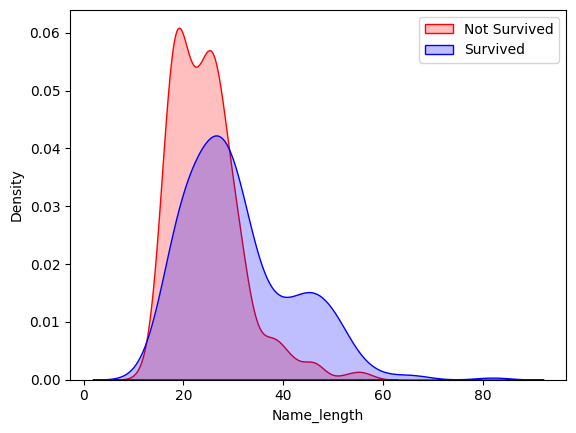

In [297]:
#This code is attempting to create a kernel density estimate (KDE) plot using Seaborn (sns.kdeplot).
#KDE is a statistical visualization technique that estimates the probability density of a continuous variable (like Name_length, which is the length of passenger names in characters). It smooths out the data to show where values are most concentrated, similar to a histogram but with a smooth curve instead of bars.
#The plot is specifically for passengers who did not survive (i.e., Survived == 0), and it's colored red with a filled area under the curve.
#In the context of your Titanic dataset analysis, this helps visualize how name lengths are distributed among non-survivors, potentially revealing patterns (e.g., do shorter/longer names correlate with survival?).
#In your notebook, you've already created Name_length and explored survival patterns (e.g., by age, fare, family size, and titles).
#This plot complements that by visualizing name length distributions. For example:
#Compare it with a similar plot for survivors (e.g., Survived == 1) to see differences.
#From your earlier cells, you have a similar KDE plot (but for both survived/didn't survive), so this isolates non-survivors.
#KDE plots are useful for continuous variables like this because they reveal "peaks" (common name lengths) and spread without binning artifacts (unlike histograms).
#GRAPH READS:there is a KDE plot that shows the distribution of name lengths for passengers who did not survive (in red) and those who survived (in blue). The x-axis represents the length of the names, while the y-axis represents the density (or frequency) of passengers with those name lengths. By comparing the two curves, we find out that people who survived had longer names on average than those who did not.this suggests that the long names were either associated with higher social status or certain titles that had better chances of survival, while shorter names might have been more common among those who did not survive. This insight can be valuable for feature engineering in predictive modeling.

g = sns.kdeplot(train_df['Name_length'][(train_df['Survived'] == 0) & (train_df['Name_length'].notnull())], color='red', fill=True)
g = sns.kdeplot(train_df['Name_length'][(train_df['Survived'] == 1) & (train_df['Name_length'].notnull())], color='blue', fill=True)
g = g.legend(['Not Survived', 'Survived'])


In [298]:
train_df['Name_lengthGB']=pd.qcut(train_df['Name_length'], q=8, labels=False)
test_df['Name_lengthGB']=pd.qcut(test_df['Name_length'], q=8, labels=False)

In [299]:
train_df.groupby('Name_lengthGB', as_index=False)['Survived'].mean()

,Name_lengthGB,Survived
0,0,0.214286
1,1,0.252427
2,2,0.307692
3,3,0.346939
4,4,0.292929
5,5,0.428571
6,6,0.517241
7,7,0.745283


In [300]:
train_df.loc[train_df['Name_length']<=18.0, 'Name_lengthGB']=0
train_df.loc[(train_df['Name_length']>18.0) & (train_df['Name_lengthGB']<=20.0), 'Name_SIZE']=1
train_df.loc[(train_df['Name_length']>20.0) & (train_df['Name_lengthGB']<=23.0), 'Name_SIZE']=2
train_df.loc[(train_df['Name_length']>23.0) & (train_df['Name_lengthGB']<=25.0), 'Name_SIZE']=3
train_df.loc[(train_df['Name_length']>25.0) & (train_df['Name_lengthGB']<=27.0), 'Name_SIZE']=4
train_df.loc[(train_df['Name_length']>27.0) & (train_df['Name_lengthGB']<=30.0), 'Name_SIZE']=5
train_df.loc[(train_df['Name_length']>30.0) & (train_df['Name_lengthGB']<=38.0), 'Name_SIZE']=6
train_df.loc[(train_df['Name_length']>38.0) & (train_df['Name_lengthGB']<=82.0), 'Name_SIZE']=7

test_df.loc[test_df['Name_length']<=18.0, 'Name_lengthGB']=0
test_df.loc[(test_df['Name_length']>18.0) & (test_df['Name_lengthGB']<=20.0), 'Name_SIZE']=1
test_df.loc[(test_df['Name_length']>20.0) & (test_df['Name_lengthGB']<=23.0), 'Name_SIZE']=2
test_df.loc[(test_df['Name_length']>23.0) & (test_df['Name_lengthGB']<=25.0), 'Name_SIZE']=3
test_df.loc[(test_df['Name_length']>25.0) & (test_df['Name_lengthGB']<=27.0), 'Name_SIZE']=4
test_df.loc[(test_df['Name_length']>27.0) & (test_df['Name_lengthGB']<=30.0), 'Name_SIZE']=5
test_df.loc[(test_df['Name_length']>30.0) & (test_df['Name_lengthGB']<=38.0), 'Name_SIZE']=6
test_df.loc[(test_df['Name_length']>38.0) & (test_df['Name_lengthGB']<=82.0), 'Name_SIZE']=7


In [301]:
train_df.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilySizeGroup,Age_cut,Fare_cut,Title,Name_length,Name_lengthGB,Name_SIZE
0,1,0,3,"Braund, Mr. Owen Harris",male,2.0,1,0,A/5 21171,0.0,NaN,S,1,Alone,"(20.125, 24.0]","(-0.001, 7.775]",Mr,23,2,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,5.0,1,0,PC 17599,5.0,C85,C,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs,51,7,7.0
2,3,1,3,"Heikkinen, Miss. Laina",female,3.0,0,0,STON/O2. 3101282,1.0,NaN,S,0,Alone,"(24.0, 28.0]","(7.775, 8.662]",Unmarried,22,2,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,5.0,1,0,113803,5.0,C123,S,1,Alone,"(32.312, 38.0]","(52.369, 512.329]",Mrs,44,7,7.0
4,5,0,3,"Allen, Mr. William Henry",male,5.0,0,0,373450,1.0,NaN,S,0,Alone,"(32.312, 38.0]","(7.775, 8.662]",Mr,24,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,1.0,NaN,S,0,Alone,NaN,"(7.775, 8.662]",Mr,27,4,4.0
96,97,0,1,"Goldschmidt, Mr. George B",male,7.0,0,0,PC 17754,4.0,A5,C,0,Alone,"(47.0, 80.0]","(26.0, 52.369]",Mr,25,3,3.0
97,98,1,1,"Greenfield, Mr. William Bertram",male,2.0,0,1,PC 17759,5.0,D10 D12,C,1,Alone,"(20.125, 24.0]","(52.369, 512.329]",Mr,31,6,6.0
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,5.0,0,1,231919,3.0,NaN,S,1,Alone,"(32.312, 38.0]","(14.454, 26.0]",Mrs,36,6,6.0


In [302]:
train_df['Ticket_number']=train_df['Ticket'].apply(lambda x: pd.Series({'Ticket' :x.split() [-1]}))
test_df['Ticket_number']=test_df['Ticket'].apply(lambda x: pd.Series({'Ticket' :x.split() [-1]}))

In [306]:
train_df.groupby(['Ticket_number'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values(by='count', ascending=False)

,Ticket_number,count,mean
196,2343,7,0.000000
464,347082,7,0.000000
94,1601,7,0.714286
168,2144,6,0.000000
468,347088,6,0.000000
...,...,...,...
674,8475,1,0.000000
675,851,1,0.000000
676,9234,1,1.000000
63,11769,1,1.000000


In [309]:
#This process is used to count the number of occurrences of each unique ticket number in the 'Ticket_number' column of the train_df DataFrame. The groupby function groups the data by 'Ticket_number', and then the transform('count') function counts how many times each ticket number appears in the dataset. This can be useful for feature engineering, as it may indicate whether passengers with the same ticket number (possibly traveling together) had different survival rates, which could be a significant factor in predicting survival on the Titanic.
train_df['Ticket_count']=train_df.groupby('Ticket_number')['Ticket_number'].transform('count')
test_df['Ticket_count']=test_df.groupby('Ticket_number')['Ticket_number'].transform('count')

In [313]:
train_df.groupby(['Ticket_count'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values(by='count', ascending=False)

,Ticket_count,count,mean
0,1,544,0.295956
1,2,188,0.569149
2,3,66,0.712121
3,4,44,0.500000
6,7,21,0.238095
5,6,18,0.000000
4,5,10,0.000000
